Libraries and other imports

In [196]:
import numpy as np
import scipy.linalg as la
from scipy.linalg import solve
import matplotlib.pyplot as plt

Helper Functions

In [213]:
def print_matrix(matrix):
    for row in matrix:
        print(" ".join(map(str, row)))

def extract_LU(A): # This is for printing purposes only (for toy example testing).
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i > j:
                L[i, j] = A[i, j]
            else:
                U[i, j] = A[i, j]
    return L, U


Routines

In [198]:
def lu_factorization(A, pivot_type='no', threshold=1e-12):
    A = np.array(A, dtype=float)  # I want to ensure double-precision even for integer-valued matrices
    n = A.shape[0]
    P_r = np.arange(n)  # Row permutation array initialised as [0 1 ... n-1]
    P_c = np.arange(n)  # Column permutation array for complete pivoting
    
    # Loop over the first n-1 columns (no need for computation in the last column)
    for i in range(n - 1):
        # Handle pivoting based on the selected method
        if pivot_type == 'partial':
            # Partial pivoting: Find the largest pivot in the current column manually
            max_row = i
            for j in range(i + 1, n):
                if abs(A[j, i]) > abs(A[max_row, i]):
                    max_row = j

            # Check the pivot size against the threshold
            if abs(A[max_row, i]) < threshold:
                print(f"Warning: Pivot element {A[max_row, i]} below threshold at step {i}")

            # Swap rows if necessary
            if max_row != i:
                A[[i, max_row]] = A[[max_row, i]]  # Swap rows in matrix A
                P_r[i] = max_row  # Record row permutation

        elif pivot_type == 'complete':
            # Complete pivoting: Find the largest pivot in the active submatrix
            max_row, max_col = i, i
            max_val = abs(A[i, i])
            for r in range(i, n):
                for c in range(i, n):
                    if abs(A[r, c]) > max_val:
                        max_row, max_col, max_val = r, c, abs(A[r, c])

            if max_val < threshold:
                print(f"Warning: Pivot element {max_val} below threshold at step {i}")

            # Swap rows if necessary
            if max_row != i:
                A[[i, max_row]] = A[[max_row, i]]
                P_r[i] = max_row  # Record row permutation

            # Swap columns if necessary
            if max_col != i:
                A[:, [i, max_col]] = A[:, [max_col, i]]
                P_c[i] = max_col  # Record column permutation

        elif pivot_type == 'no':
            # No pivoting: Just issue a warning if the pivot is small or exit if pivot is 0 (This may happen for no pivoting)
            if A[i][i] == 0:
                ValueError("Pivot entry at step",{i},"is 0. LU Factorization does not exist")
            if abs(A[i, i]) < threshold:
                print(f"Warning: Pivot element {A[i, i]} below threshold at step {i}")
            

        # Perform elimination for the current pivot
        for j in range(i + 1, n):
            A[j, i] /= A[i, i]  # This is L[j, i]
            for k in range(i + 1, n):
                A[j, k] -= A[j, i] * A[i, k]  # This calculates the Schur complement

    if pivot_type == 'partial':
        return A, P_r  # Return matrix and row permutation array
    elif pivot_type == 'complete':
        return A, P_r, P_c  # Return matrix, row and column permutation arrays
    else:
        return A  # Return just the matrix for no pivoting (I dont want to store unnecessary arrays)
    

    
def lu_product(A): # From program 1
    n = A.shape[0]

    M = np.zeros((n, n))
    if(n==1):
        M = A
    else:
        # Assign the first row directly from U
        for i in range(n):
            M[0][i] = A[0][i]
        
        # Compute the first column of M
        for i in range(1, n):
            M[i][0] = A[i][0] * A[0][0]
        
        # Compute the rest
        for i in range(1, n):
            for j in range(1, n):
                # Calculate the minimum limit for iteration
                min_val = j+1
                if((min_val - i) >0):
                    min_val = i
                
                # Inner product for the lower and upper parts of the matrix
                index = 0
                for k in range(min_val):
                    M[i][j] += A[i][k] * A[k][j]
                    index += 1
                
                # Add the diagonal element (implicitly 1 for L)
                if (i <= j):
                    M[i][j] += A[index][j]
    
    return M

def apply_row_permutations(X, P_r):
    X_permuted = np.copy(X)  # Make a copy to avoid modifying the original array
    n = len(P_r)

    for i in range(n):
        swap_with = P_r[i]
        if i != swap_with:
            X_permuted[[i, swap_with]] = X_permuted[[swap_with, i]]  # Swap rows

    return X_permuted

def apply_column_permutations(X, P_c):
    X_permuted = np.copy(X)  # Make a copy to avoid modifying the original array
    n = len(P_c)

    for i in range(n):
        swap_with = P_c[i]
        if i != swap_with:
            X_permuted[:, [i, swap_with]] = X_permuted[:, [swap_with, i]]  # Swap columns

    return X_permuted

def apply_full_permutation(X, P_r, P_c):
    X_permuted = apply_row_permutations(X, P_r)
    X_permuted = apply_column_permutations(X_permuted, P_c)

    return X_permuted

def apply_column_permutations_reverse(x, P_c): # For Qx in complete pivoting
    x_permuted = np.copy(x)
    n = len(P_c)

    # Apply swaps in reverse order
    for i in range(n - 1, -1, -1):
        swap_with = P_c[i]
        if i != swap_with:
            x_permuted[[i, swap_with]] = x_permuted[[swap_with, i]]  # Swap rows

    return x_permuted

def solve_lower(A, b):
    n = len(b)
    c = np.zeros_like(b, dtype=float)

    # Forward substitution: Solve for c in Lc = b
    c[0] = b[0]
    for i in range(1,n):
        sum_value = 0.0
        for j in range(i):  # Only consider elements below the diagonal
            sum_value += A[i, j] * c[j]
        c[i] = (b[i] - sum_value)  # Diagonal element L[i, i] is implicitly 1 so no division

    return c

def solve_upper(A, c):
    n = len(c)
    x = np.zeros_like(c, dtype=float)

    # Backward substitution: Solve for x in Ux = c
    for i in range(n - 1, -1, -1): # Row index going the opposite way from n-1 to 0
        sum_value = 0.0
        for j in range(i + 1, n):  # Only consider elements to the right of the diagonal
            sum_value += A[i, j] * x[j]
        x[i] = (c[i] - sum_value) / A[i, i]  # Use the diagonal element of U

    return x

def solve_system(A, b, P_r=None, P_c=None):
    if P_r is not None:
        b = apply_row_permutations(b, P_r)

    c = solve_lower(A, b)

    # Solve Ux' = c using backward substitution (x' is the permuted solution)
    x_prime = solve_upper(A, c)

    # Apply column permutation in reverse order to x' to get the final solution x
    if P_c is not None:
        x_prime = apply_column_permutations_reverse(x_prime, P_c)
        
    return x_prime

def infinity_norm(X):
    if X.ndim == 1:
        max_value = 0.0
        for i in range(len(X)):
            abs_value = abs(X[i])
            if abs_value > max_value:
                max_value = abs_value
        return max_value

    elif X.ndim == 2:
        max_row_sum = 0.0
        for i in range(X.shape[0]):
            row_sum = 0.0
            # Calculate the sum of absolute values in the current row
            for j in range(X.shape[1]):
                row_sum += abs(X[i, j])
            # Update the max row sum if this row's sum is larger
            if row_sum > max_row_sum:
                max_row_sum = row_sum
        return max_row_sum

    else:
        raise ValueError("Input must be a 1D vector or 2D matrix.")

Metrics and Helper Functions

In [199]:
def generate_full_rank_matrix(n, low=1, high=10):
    # Generate a unit lower triangular matrix L (with ones on the diagonal)
    L = np.tril(np.random.randint(low, high, size=(n, n)).astype(float))
    np.fill_diagonal(L, 1)  # Make it unit lower triangular

    # Generate a random upper triangular matrix U
    U = np.triu(np.random.randint(low, high, size=(n, n)).astype(float))

    # Calculate A = L * U
    A = np.dot(L, U)
    return A

def generate_symmetric_positive_definite_matrix(n, low=1, high=10):
    # Generate a random lower triangular matrix L with positive diagonal elements
    L = np.tril(np.random.randint(low, high, size=(n, n)).astype(float))
    np.fill_diagonal(L, np.random.uniform(1, high, size=n))  # Positive diagonal elements

    A = L @ L.T

    return A

def generate_random_vector(n, low=-10, high=10):
    return np.random.randint(low, high + 1, size=n).astype(float)

def factorization_accuracy(A, A_user, P_r=None, P_c=None):
    n = A.shape[0]
    if P_r is not None:
        A = apply_row_permutations(A, P_r)
    if P_c is not None:
        A = apply_column_permutations(A, P_c)

    A_reconstructed = lu_product(A_user)
    error_matrix = A - A_reconstructed

    relative_error = infinity_norm(error_matrix) / infinity_norm(A)

    return relative_error

def compute_residual(A, x, b):
    residual = b - A @ x
    return la.norm(residual) / la.norm(b)

def solution_error(x, x_computed):
    error = x - x_computed
    return la.norm(error) / la.norm(x)

Testing Driver

C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\920566772.py:19: LinAlgWarning: Ill-conditioned matrix (rcond=1.99919e-17): result may not be accurate.
  x_true = solve(A_spd, b)
C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\920566772.py:19: LinAlgWarning: Ill-conditioned matrix (rcond=2.73084e-18): result may not be accurate.
  x_true = solve(A_spd, b)
C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\920566772.py:19: LinAlgWarning: Ill-conditioned matrix (rcond=1.8115e-17): result may not be accurate.
  x_true = solve(A_spd, b)
C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\920566772.py:19: LinAlgWarning: Ill-conditioned matrix (rcond=9.85546e-18): result may not be accurate.
  x_true = solve(A_spd, b)
C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\920566772.py:19: LinAlgWarning: Ill-conditioned matrix (rcond=1.55581e-18): result may not be accurate.
  x_true = solve(A_spd, b)
C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\920566772.py:19: LinAlgWarning: Ill-conditioned matr


No Pivoting:
Factorization Error - Mean: 0.000000, Variance: 0.000000
Residual - Mean: 37.151377, Variance: 101205.003011
Solution Error - Mean: 3.796198, Variance: 251.520520


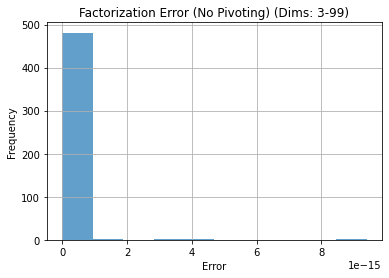

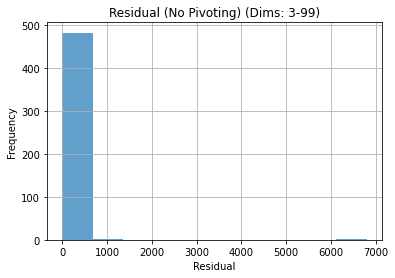

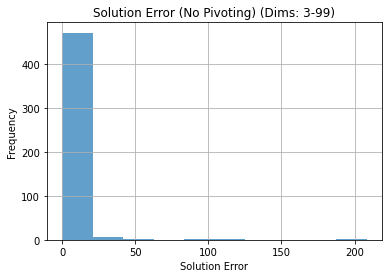


Partial Pivoting:
Factorization Error - Mean: 0.746349, Variance: 0.587918
Residual - Mean: 85.570516, Variance: 2225864.932617
Solution Error - Mean: 2.041398, Variance: 48.289387


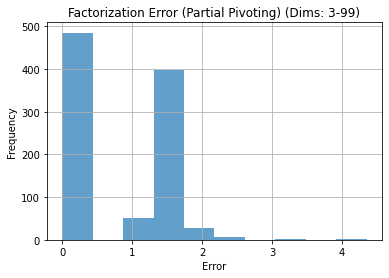

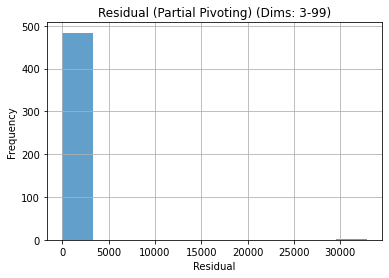

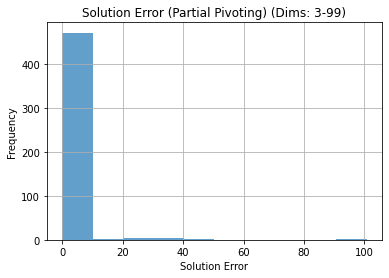

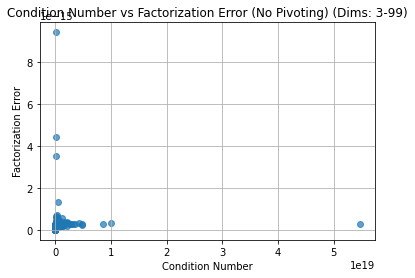

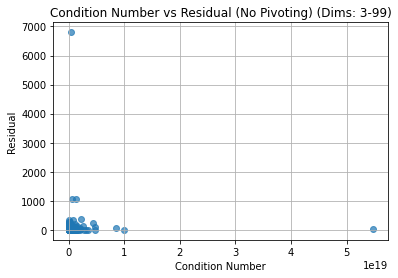

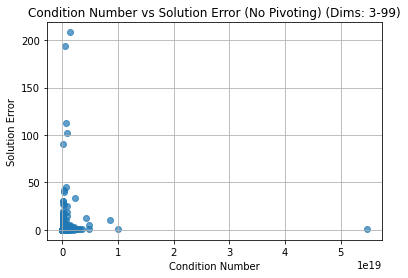

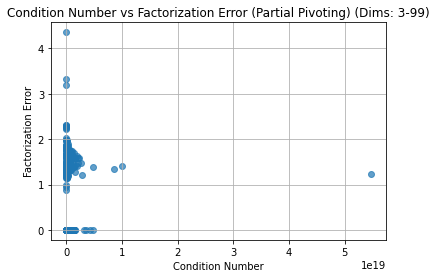

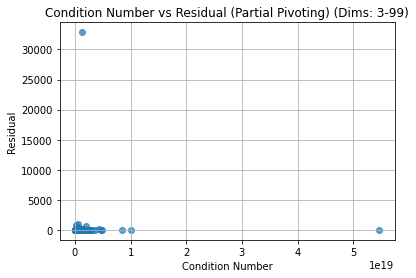

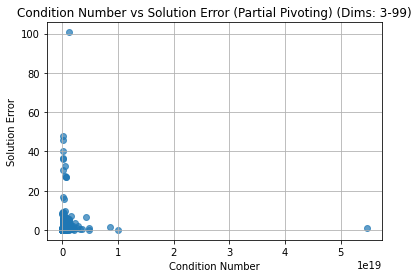

In [212]:
def test_lu_factorization(dims=range(3, 100), low=-50, high=50, num_tests=5):
    results_no_pivot = {"factor_error": [], "residual": [], "solution_error": [], "cond_num": []}
    results_partial_pivot = {"factor_error": [], "residual": [], "solution_error": [], "cond_num": []}

    # Loop over dimensions
    for n in dims:
        for _ in range(num_tests):
            try:
                # Generate SPD matrix
                A_spd = generate_symmetric_positive_definite_matrix(n, low, high)
                b = generate_random_vector(n, low, high)

                # Compute condition number
                cond_num = np.linalg.cond(A_spd)

                # No pivoting test
                A_lu = lu_factorization(A_spd.copy(), pivot_type='no')
                x_computed = solve_system(A_lu, b)
                x_true = solve(A_spd, b)

                # Metrics for no pivoting
                factor_error = factorization_accuracy(A_spd, A_lu)
                residual = compute_residual(A_spd, x_computed, b)
                solution_err = solution_error(x_true, x_computed)

                # Store metrics and condition number
                results_no_pivot["cond_num"].append(cond_num)
                results_no_pivot["factor_error"].append(factor_error)
                results_no_pivot["residual"].append(residual)
                results_no_pivot["solution_error"].append(solution_err)

                # Partial pivoting test
                A_lu, P_r = lu_factorization(A_spd.copy(), pivot_type='partial')
                x_computed = solve_system(A_lu, b, P_r=P_r)

                # Metrics for partial pivoting
                factor_error = factorization_accuracy(A_spd, A_lu, P_r=P_r)
                residual = compute_residual(A_spd, x_computed, b)
                solution_err = solution_error(x_true, x_computed)

                # Store metrics and condition number
                results_partial_pivot["cond_num"].append(cond_num)
                results_partial_pivot["factor_error"].append(factor_error)
                results_partial_pivot["residual"].append(residual)
                results_partial_pivot["solution_error"].append(solution_err)

                # Full-rank matrix for factorization error only
                A_full = generate_full_rank_matrix(n, low, high)
                factor_error_full_rank = factorization_accuracy(A_full, A_lu)
                results_partial_pivot["factor_error"].append(factor_error_full_rank)

            except Exception as e:
                print(f"An error occurred: {e}. Skipping this test case.")
                continue

    plot_metrics(results_no_pivot, results_partial_pivot, dims)

def plot_metrics(results_no_pivot, results_partial_pivot, dims):
    def plot_histogram(data, title, xlabel):
        plt.figure()
        plt.hist(data, bins=10, alpha=0.7)
        plt.title(f"{title} (Dims: {min(dims)}-{max(dims)})")
        plt.xlabel(xlabel)
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

    def report_statistics(errors, title):
        mean = np.mean(errors)
        variance = np.var(errors)
        print(f"{title} - Mean: {mean:.6f}, Variance: {variance:.6f}")
        return mean, variance

    # Report and plot statistics for No Pivoting
    print("\nNo Pivoting:")
    mean_factor, var_factor = report_statistics(results_no_pivot["factor_error"], "Factorization Error")
    mean_residual, var_residual = report_statistics(results_no_pivot["residual"], "Residual")
    mean_solution, var_solution = report_statistics(results_no_pivot["solution_error"], "Solution Error")

    # Plot histograms for No Pivoting
    plot_histogram(results_no_pivot["factor_error"], "Factorization Error (No Pivoting)", "Error")
    plot_histogram(results_no_pivot["residual"], "Residual (No Pivoting)", "Residual")
    plot_histogram(results_no_pivot["solution_error"], "Solution Error (No Pivoting)", "Solution Error")

    # Report and plot statistics for Partial Pivoting
    print("\nPartial Pivoting:")
    mean_factor_p, var_factor_p = report_statistics(results_partial_pivot["factor_error"], "Factorization Error")
    mean_residual_p, var_residual_p = report_statistics(results_partial_pivot["residual"], "Residual")
    mean_solution_p, var_solution_p = report_statistics(results_partial_pivot["solution_error"], "Solution Error")

    # Plot histograms for Partial Pivoting
    plot_histogram(results_partial_pivot["factor_error"], "Factorization Error (Partial Pivoting)", "Error")
    plot_histogram(results_partial_pivot["residual"], "Residual (Partial Pivoting)", "Residual")
    plot_histogram(results_partial_pivot["solution_error"], "Solution Error (Partial Pivoting)", "Solution Error")

    # Scatter plot: Condition number vs errors
    plot_condition_vs_error(results_no_pivot, results_partial_pivot, dims)

def plot_condition_vs_error(results_no_pivot, results_partial_pivot, dims):
    def scatter_plot(x, y, title, xlabel, ylabel):
        if len(x) != len(y):
            print(f"Warning: x and y have mismatched sizes (x: {len(x)}, y: {len(y)}). Adjusting to minimum size.")
            min_len = min(len(x), len(y))
            x = x[:min_len]
            y = y[:min_len]

        plt.figure()
        plt.scatter(x, y, alpha=0.7)
        plt.title(f"{title} (Dims: {min(dims)}-{max(dims)})")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.show()

    # Scatter plots for No Pivoting
    scatter_plot(
        results_no_pivot["cond_num"],
        results_no_pivot["factor_error"],
        "Condition Number vs Factorization Error (No Pivoting)",
        "Condition Number",
        "Factorization Error",
    )
    scatter_plot(
        results_no_pivot["cond_num"],
        results_no_pivot["residual"],
        "Condition Number vs Residual (No Pivoting)",
        "Condition Number",
        "Residual",
    )
    scatter_plot(
        results_no_pivot["cond_num"],
        results_no_pivot["solution_error"],
        "Condition Number vs Solution Error (No Pivoting)",
        "Condition Number",
        "Solution Error",
    )

    # Scatter plots for Partial Pivoting
    scatter_plot(
        results_partial_pivot["cond_num"],
        results_partial_pivot["factor_error"],
        "Condition Number vs Factorization Error (Partial Pivoting)",
        "Condition Number",
        "Factorization Error",
    )
    scatter_plot(
        results_partial_pivot["cond_num"],
        results_partial_pivot["residual"],
        "Condition Number vs Residual (Partial Pivoting)",
        "Condition Number",
        "Residual",
    )
    scatter_plot(
        results_partial_pivot["cond_num"],
        results_partial_pivot["solution_error"],
        "Condition Number vs Solution Error (Partial Pivoting)",
        "Condition Number",
        "Solution Error",
    )

# Run the testing driver
test_lu_factorization()
